# **AS-IS Processs — 3LoD Scenario for a Suspicious Transaction Case**

## **Definition of Suspiciousness Labels**

In this research, I create suspicious levels in the three levels—low, medium, and high—based on the degree of deviation from historical transaction behavior and the customer's profile, rather than on absolute transaction values or as confirmation of fraud. These levels represent early operational risk signals and are used to support grouping, review, and escalation within the Three Lines of Defense. The definitions applied to each level of suspiciousness are summarized below:


### **Table 1. Definition of Suspiciousness Labels Based on Deviation from Customer-Specific Historical & Profile Base line Baselines**

| Suspiciousness Label | Definition                                                                                                                                                                 | Deviation Logic (Conceptual)                                                                                                              | Operational Implication                                                                  |
| -------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **Low**              | Transaction behavior remains consistent with the customer’s historical transaction patterns and reflects normal operational variation for the customer profile.            | Minor or no deviation from the customer-specific historical transaction baseline, interpreted within the context of the customer profile. | No escalation required. Transaction treated as normal operational activity.              |
| **Medium**           | Transaction behavior shows a noticeable deviation from historical patterns but may still be explainable by business or contextual factors related to the customer profile. | Moderate deviation from the customer-specific historical baseline, indicating a potential early risk signal.                              | Requires increased attention or monitoring by the first line. Escalation is conditional. |
| **High**             | Transaction behavior exhibits an extreme and unusual deviation from historical patterns that is unlikely to represent normal variation for the given customer profile.     | Significant deviation from the customer-specific historical baseline, indicating elevated risk.                                           | Triggers escalation to the second line for independent review and risk assessment.       |


## **Operational Thresholds for Suspiciousness Labels**

### **Table 2. Threshold Definition for Mapping Deviations to Suspiciousness Levels**

| Dimension                            | Metric                                                                      | Baseline Definition                               | Threshold Logic            | Notes                                                                                                             |
| ------------------------------------ | --------------------------------------------------------------------------- | ------------------------------------------------- | -------------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **Transaction Frequency (Velocity)** | Ratio of daily transaction count to customer historical daily average       | Customer-specific historical transaction behavior | ≤ 1.2× / 1.2–2.0× / > 2.0× | Threshold interpretation is contextualized by customer profile (e.g., customer segment, product characteristics). |
| **Transaction Amount (Value)**       | Ratio of daily or monthly transaction amount to customer historical average | Customer-specific historical transaction behavior | ≤ 1.2× / 1.2–2.0× / > 2.0× | Baseline reflects transaction sizes that are typical for the customer profile.                                    |


**Note:**

Baselines are calculated using customer-specific historical transaction data. Customer profiles are used to contextualize the interpretation of deviations, rather than to define separate numerical baselines or thresholds. The thresholds presented are illustrative and intended to support transparent and explainable risk labeling.

## **Methodology (Step by Step) For Grouping & Labeling of Suspicious Transactions**

This study adopts a simple, deviation-based approach to illustrate how suspiciousness labels are generated and propagated within the Three Lines of Defense (3LoD). The objective is governance transparency and interpretability rather than detection accuracy.

### **Step 1 — Transaction Grouping**

The input data consist of transaction-level records (one row per `txn_id`). Transactions are aggregated to the **customer-day** level to capture velocity-based anomalies.

For each `client_id` and `date`, the following daily indicators are computed:

**1) Daily transaction frequency (velocity)**  

`daily_txn_count = number of transactions per customer per day`


- **Formula:**

$$
daily\_txn\_count_{i,t} = \#(\text{transactions of customer } i \text{ on day } t)
$$



**2) Daily transaction value (amount)**  

`daily_total_amount = sum of amount_eur per customer per day`

- **Formula:**

$$
daily\_total\_amount_{i,t} = \sum(\text{amount\_eur of customer } i \text{ on day } t)
$$

**3) (Optional) Daily average amount**  

`daily_avg_amount = daily_total_amount / daily_txn_count`

- **Formula:**

$$
daily\_avg\_amount_{i,t} = \frac{daily\_total\_amount_{i,t}}{daily\_txn\_count_{i,t}}
$$


**Rationale:** Velocity spikes are most visible at the daily aggregation level.

### **Step 2 — Customer-Specific Historical Baselines**

For each customer $i$, a historical baseline is calculated from prior observations to represent the customer’s “normal” behavior. Two baselines are defined:

**1) Baseline daily frequency**  

`baseline_txn_count = historical average of daily_txn_count`
  
- **Formula:**

$$ baseline\_txn\_count_{i,t} = \text{historical average of } daily\_txn\_count_{i,\tau} \text{ for } \tau < t
$$

**2) Baseline daily amount**  

- `baseline_total_amount = historical average of daily_total_amount`

- **Formula:**
$$
baseline\_total\_amount_{i,t} = \text{historical average of } daily\_total\_amount_{i,\tau} \text{ for } \tau < t
$$


Baselines may be calculated using:
- rolling windows (e.g., last 30 days), or
- expanding historical means.

To avoid look-ahead bias, baselines are computed using **historical data only**, excluding the current day $t$.

### **Step 3 — Deviation Ratios**

Deviation from historical behavior is expressed as ratios:

**1) Velocity ratio**  

`ratio_velocity = daily_txn_count / baseline_txn_count`

- **Formula:**
$$
ratio\_velocity_{i,t} = \frac{daily\_txn\_count_{i,t}}{baseline\_txn\_count_{i,t}}
$$

**2) Value ratio**  

`ratio_value = daily_total_amount / baseline_total_amount`

- **Formula:**
$$
ratio\_value_{i,t} = \frac{daily\_total\_amount_{i,t}}{baseline\_total\_amount_{i,t}}
$$

These ratios serve as interpretable, deviation-based indicators for subsequent grouping.

### **Step 4 — Deviation Grouping**

Each ratio is mapped into one of three deviation groups:

| Ratio vs Baseline | Deviation Group |
|-------------------|-----------------|
| ≤ 1.2× | Normal |
| > 1.2× and ≤ 2.0× | Elevated |
| > 2.0× | Significant |

Grouping is applied separately to velocity and value.

- Velocity -> ``group_velocity``

- Value -> ``group_value``

#### **Threshold Assumption and Rationale**

I define thresholds within the ranges of ≤1.2, 1.2–2.0, and >2.0, and these are not universal AML thresholds. These thresholds were intentionally chosen as simple and easily interpreted ranges to operationalize the concept of transaction deviations labeled as normal, high, and significant in simulated suspicious transaction scenarios with a focus on governance.

This thesis does not aim to optimize suspicious transaction detection accuracy, but rather to demonstrate traceable labeling, review, and escalation across the Three Lines of Defense in operational activity related to suspicious transactions. Because deviations are calculated relative to a customer-specific historical baseline (per customer), rather than population transaction data, this approach adapts to the typical activity level of each customer in a given retail sample (subject to data availability).

#### **Business Interpretation of Thresholds**

The selected ranges reflect increasing levels of operational attention. Small day-to-day variations (approximately ±20%) are commonly observed in routine transaction behavior and are therefore treated as operational noise. Deviations between 20% and 100% represent material changes that can still be explained by business or contextual factors. Deviations exceeding 100% indicate significant behavioral changes that are rare under steady-state conditions and therefore require escalation.

Because the deviation ratio is calculated at the individual customer level rather than across the entire customer population, small fluctuations are interpreted as within-customer variability rather than as a risk signal. In this study, deviations up to approximately 20% from a customer's historical baseline are assumed to reflect normal transactional noise. Therefore, a ratio threshold of 1.2× is used to define normal behavior, while higher ratios indicate an increased level of concern.

This deviation ratio approach emphasizes the importance of interpretability and robustness within a governance-focused environment. We did not use distribution-based statistical methods, such as percentiles or interquartile ranges (IQRs), as the main labeling mechanism because they can lead to instability when there are limited or uneven historical observations for each customer. Therefore, these methods are more appropriate for sensitivity analysis than for core operationalization in this context.

To assess robustness, alternative tolerance margins (e.g., 30%) are also considered. These margins represent a wider range of normal operational variability than the data proportions. As result, patterns label and governance conclusions remain consistent under this reasonable variation. Overall, fixed thresholds are used because the goal is transparent governance modeling, not statistical optimality. Thresholds are applied at the customer level, interpretations are prioritized, and robustness is verified through alternative assumptions.

#### **Illustrative Examples: Application of Tolerance Margins at the Customer Level**

Below, I will illustrate how thresholds are set for each individual customer case (e.g., 20% and 30%) to distinguish normal operational variability from meaningful deviations. These examples aim to clarify that tolerance limits represent the acceptable range of deviations around the customer's historical baseline, not data proportions, sampling assumptions, or statistical threshold rules.

The customer's profile and transactions case below are presented as examples of two customers with distinct profile and transaction patterns.

| Dimension | Customer A (Stable Pattern) | Customer B (Irregular Pattern) |
|--------|-----------------------------|--------------------------------|
| Customer profile | Retail, relatively stable behavior | Retail, higher historical variability |
| Historical avg. daily transaction count | 10 | 10 |
| Historical avg. daily transaction value (€) | 200 | 200 |
| Observed daily transaction count | 12 | 13 |
| Observed daily transaction value (€) | 215 | 240 |
| Velocity ratio | 1.20 | 1.30 |
| Value ratio | 1.08 | 1.20 |
| Tolerance margin applied | 20% | 20% |
| Interpretation | Normal operational variability | Deviation exceeds tolerance |
| Assigned suspiciousness label | Low | Medium |
| Escalation required | No | Conditional |


Interpretation using a 30% tolerance margin (robustness check)
When a wider tolerance margin is applied, the observed deviation remains within the acceptable range of normal variability for this customer. With these alternative tolerance margins, the same behavior would not trigger an escalation and will assigned label as Low Suspicion

This comparison illustrates how alternative tolerance assumptions can accommodate customers with inherently irregular transaction patterns without changing the governance structure or underlying labeling logic.

### **Methodological Interpretation for two different customers' cases**

These examples demonstrate that the tolerance margin defines how much deviation from a customer's historical baseline is considered normal operational variability, rather than how the data is statistically partitioned or sampled.

Although socio-demographic attributes such as occupation are not available in the dataset, the customer profiles in this study are operationally defined using observed transaction behavior, product relationships, and historical variability. This approach is used to illustrate common governance and auditing practices, in which deviations are assessed relative to the customer's historical behavior rather than inferred from external characteristics.

As a result, even though the deviation ratio appears higher in absolute terms for Customer B than for Customer A, the interpretation may differ between customers due to differences in behavioral patterns and the breakdown of variability. The labeling logic itself must remain consistent across all customers. Meanwhile, data interpretation and follow-up actions are contextualized within the Three Lines of Defense framework using a human judgment approach. This approach reduces the risk of misclassifying normal but unusual behavior as suspicious while maintaining traceability, transparency, and governance integrity.

In the area of Governance, Risk, and Compliance (GRC), the most important factor is informed, accountable, and responsible human judgment in fulfilling their roles. This assessment should be carried out using a clear, documented, and transparent methodology, rather than relying solely on isolated numerical metrics.

in this case, quantitative indicators can serve as a tool to support decision-making, but the results depend on human interpretation, escalation, and risk management responsibilities fall to the relevant functions within the GRC framework. This approach enables the implementation of controls that are proportionate to the level of risk and aligned with the organization's risk appetite and risk controls, as well as applicable regulatory requirements, while avoiding unnecessary disruption to business and operational processes.

> EBA AML Guidelines -> risk-based assessment with documented rationale

> GDPR Art. 22 -> human review for automated decisions

> DORA -> human oversight over ICT risk & monitoring

> IIA Europe -> professional judgment in assurance & governance


### **Step 5 — Mapping to Suspiciousness Labels**

Final suspiciousness labels are derived as follows:

- **High**: at least one dimension is *Significant*
- **Medium**: no *Significant*, but at least one *Elevated*
- **Low**: both dimensions are *Normal*

| Velocity Group | Value Group | Suspiciousness Label |
|---------------|-------------|----------------------|
| Normal | Normal | Low |
| Elevated | Normal | Medium |
| Normal | Elevated | Medium |
| Elevated | Elevated | Medium |
| Significant | Any | High |
| Any | Significant | High |

**Interpretation:** Labels represent early operational risk signals and do not confirm fraud or suspicious activity.

### **Transaction-Level Assignment**

Although labels are generated at the customer-day level, they can be propagated back to transaction-level records using (`client_id`, `date`) joins.

### **Baseline Availability**

For customers with insufficient historical data, labeling is deferred or defaulted to low suspiciousness until an adequate baseline is established.


## **Example Grouping and Labeling of Suspicious Transactions (Illustration Condition)**


### **Table 3. Illustrative Examples of Grouping and Labeling Based on Deviation from Customer-Specific Baselines**

| Case | Customer Type (Profile Context)      | Baseline Daily Txn Count | Baseline Daily Amount (€) | Observed Daily Txn Count | Observed Daily Amount (€) | Velocity Ratio | Value Ratio | Velocity Group | Value Group | Final Suspiciousness Label | Interpretation                                                                               |
| ---- | ------------------------------------ | ------------------------ | ------------------------- | ------------------------ | ------------------------- | -------------- | ----------- | -------------- | ----------- | -------------------------- | -------------------------------------------------------------------------------------------- |
| A    | Retail customer (low activity)       | 10                       | 200                       | 11                       | 210                       | 1.10×          | 1.05×       | Normal         | Normal      | **Low**                    | Transaction behavior remains within normal historical variation.                             |
| B    | Retail customer (stable profile)     | 10                       | 200                       | 17                       | 220                       | 1.70×          | 1.10×       | Elevated       | Normal      | **Medium**                 | Increase in transaction frequency but total value remains within expected range.             |
| C    | Retail customer                      | 10                       | 200                       | 30                       | 260                       | 3.00×          | 1.30×       | Significant    | Elevated    | **High**                   | Sudden and extreme increase in transaction frequency indicates elevated operational risk.    |
| D    | Retail customer (low volume)         | 4                        | 80                        | 5                        | 220                       | 1.25×          | 2.75×       | Elevated       | Significant | **High**                   | Transaction amount deviates significantly from historical behavior despite modest frequency. |

**Note:**

1. In this case, we only focus on **retail customer** which label in the dataset as **Private Segment**.
2. The illustration above demonstrates how transaction data is **grouped and mapped to suspicious labels** based on deviations from customer-specific historical benchmarks. **Customer profiles are used to interpret the case contextually but do not amend the applied numerical thresholds.**

## **AS-IS Processs: Transaction-Based Suspiciousness Labeling: Step-by-Step Process**


```mermaid

flowchart TD
 
  A["Input: Raw transactions (one row per txn_id)"] --> B["Preprocess: parse date/time; cast amount_eur; handle missing client_id_fk"]

  B --> C["Step 1: Aggregate to customer-day (group by client_id_fk, book_date)"]
  C --> C1["Compute daily metrics: daily_txn_count; daily_total_amount_eur; (optional) daily_avg_amount_eur"]

  C1 --> D["Step 2: Build customer-specific baselines (historical only)"]
  D --> D1["Choose baseline method: rolling window (e.g., 30 days) OR expanding mean"]
  D1 --> D2["Compute baselines per customer: baseline_txn_count; baseline_total_amount_eur"]

  D2 --> E["Step 3: Compute deviation ratios"]
  E --> E1["ratio_velocity = daily_txn_count / baseline_txn_count"]
  E --> E2["ratio_value = daily_total_amount_eur / baseline_total_amount_eur"]

  E1 --> F["Step 4: Deviation grouping (velocity)"]
  E2 --> G["Step 4: Deviation grouping (value)"]

  F --> F1{"ratio_velocity <= 1.2?"}
  F1 -- "Yes" --> F2["velocity_group = Normal"]
  F1 -- "No" --> F3{"ratio_velocity <= 2.0?"}
  F3 -- "Yes" --> F4["velocity_group = Elevated"]
  F3 -- "No" --> F5["velocity_group = Significant"]

  G --> G1{"ratio_value <= 1.2?"}
  G1 -- "Yes" --> G2["value_group = Normal"]
  G1 -- "No" --> G3{"ratio_value <= 2.0?"}
  G3 -- "Yes" --> G4["value_group = Elevated"]
  G3 -- "No" --> G5["value_group = Significant"]

  F2 --> H["Step 5: Map groups to suspiciousness label"]
  F4 --> H
  F5 --> H
  G2 --> H
  G4 --> H
  G5 --> H

  H --> H1{"Any group = Significant?"}
  H1 -- "Yes" --> H2["label = High"]
  H1 -- "No" --> H3{"Any group = Elevated?"}
  H3 -- "Yes" --> H4["label = Medium"]
  H3 -- "No" --> H5["label = Low"]

  H2 --> I["Output: customer-day labels (client_id, date, metrics, ratios, groups, label)"]
  H4 --> I
  H5 --> I

  I --> J{"Optional: propagate to txn-level?"}
  J -- "Yes" --> K["Join labels back to transactions on (client_id_fk, book_date)"]
  J -- "No" --> L["End"]
  K --> L

```

## **References:**

Ali, A., Abd Razak, S., Othman, S. H., Eisa, T. A. E., Al-Dhaqm, A., Nasser, M., Elhassan, T., Elshafie, H., & Saif, A. (2022). Financial fraud detection based on machine learning: A systematic literature review. Applied Sciences, 12(19), 9637.

Gowhor, H. S. (2024). Effectiveness criteria of suspicious transaction reporting for early detection of terrorist financing activities. Journal of Financial Crime.

Koo, K., Park, M., & Yoon, B. (2024). A suspicious financial transaction detection model using autoencoder and risk-based approach. IEEE Access, 12, 68926–68939.

Pranavi, P., Manognasri, C., Sreekaree, P. S., & Ramana, A. V. (2025, August). Fraud detection in financial transactions with AI&ML. In 2025 World Skills Conference on Universal Data Analytics and Sciences (WorldSUAS). IEEE.

Reite, E. J., Oust, A., Bang, R. M., & Maurstad, S. (2023). Changes in credit score, transaction volume, customer characteristics, and the probability of detecting suspicious transactions. Journal of Money Laundering Control, 26(6), 1165–1182.

Wang, Y., Liu, Y., Wang, N., Li, P., Hu, J., Fu, X., Wang, W., Sun, K., Li, Q., & Xu, K. (2024, June). Enhancing fraud transaction detection via unlabeled suspicious records. In 2024 IEEE/ACM 32nd International Symposium on Quality of Service (IWQoS). IEEE.

 https://www.deloitte.com/kz/en/services/risk-advisory/analysis/3lod.html

### **Access Folder and Create Dataframe**

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [10]:
dataframes = {}

# Specify the folder path
folder_path = r'D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/'
for file in os.listdir(folder_path):
    if file.lower().endswith('.csv'):
        df_name = file.replace('.csv', '')
        full_path = os.path.join(folder_path, file)
        dataframes[df_name] = pd.read_csv(full_path)


### **Data Dictionary for Customers Table**

| Field           | Description                                                              |
| --------------- | ------------------------------------------------------------------------ |
| bank_reg_dt     | Date the customer was registered / activated in the bank                 |
| birth_dt        | Birth date for private customers; legal registration date for corporates |
| client_id       | Primary key for the customer master record                               |
| corp_group_id   | Identifier linking companies within the same corporate group             |
| gender_cd       | M / F / U (unknown or undisclosed)                                       |
| group_head_flg  | **Codes:** 1 = parent company (group head), 0 = child / subsidiary       |
| lang_pref       | Interface / communication language code (e.g., EN, ET, LV, LT, RU, DE)   |
| postal_code     | ZIP / Postal code of the customer’s address                              |
| segment         | High-level segment: Corporate / SME / Private                            |
| type_cd         | **Codes:** C = Corporate, H = Private (household / retail)               |


In [11]:
# accessing dataframe customers

customers = dataframes['customers']

customers.head()

,client_id,type_cd,segment,group_head_flg,birth_dt,gender_cd,lang_pref,postal_code,bank_reg_dt
0,CUST000001,H,Private,Parent,1977-11-19,M,EE,13075,2022-10-11
1,CUST000002,H,Private,Parent,1998-10-13,F,EE,81847,2018-05-18
2,CUST000003,H,Private,Parent,1971-09-07,F,EN,86527,2016-10-25
3,CUST000004,H,Private,Parent,1968-04-01,F,RU,13324,2023-10-15
4,CUST000005,H,Private,Parent,2006-08-15,F,RU,41926,2024-12-18


# **Customer Base Profile**

### - **Basic Data Information Customers**

In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   client_id       10000 non-null  object
 1   type_cd         10000 non-null  object
 2   segment         10000 non-null  object
 3   group_head_flg  10000 non-null  object
 4   birth_dt        10000 non-null  object
 5   gender_cd       10000 non-null  object
 6   lang_pref       10000 non-null  object
 7   postal_code     10000 non-null  int64 
 8   bank_reg_dt     10000 non-null  object
dtypes: int64(1), object(8)
memory usage: 703.3+ KB


In [13]:
customers.shape

(10000, 9)

In [14]:
# Descriptive statistics for numerical
customers.describe(include= [np.number])

,postal_code
count,10000.000000
mean,48629.488900
std,29181.841272
min,10001.000000
25%,13146.750000
50%,51665.000000
75%,75046.750000
max,94995.000000


In [15]:
# Descriptive statistics for non-numerical
customers.describe(include='object')

,client_id,type_cd,segment,group_head_flg,birth_dt,gender_cd,lang_pref,bank_reg_dt
count,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,1,1,1,7594,2,3,3967
top,CUST000001,H,Private,Parent,2006-04-18,F,EE,2024-12-28
freq,1,10000,10000,10000,6,5162,7350,20


In [16]:
customers.columns

Index(['client_id', 'type_cd', 'segment', 'group_head_flg', 'birth_dt',
       'gender_cd', 'lang_pref', 'postal_code', 'bank_reg_dt'],
      dtype='object')

### - **Checking & Handing Duplicate Values**

In [ ]:
#check how many Duplicate value in each row

duplicate_counts = customers[customers.duplicated(keep=False)].value_counts()
print(duplicate_counts)

**There is no duplicate value in the dataset**

### - **Checking & Handing Missing Values**

In [17]:
# check NA in each row
nan_rows = customers.isna().any(axis=1)
print("NA in rows information:")
display(nan_rows)

#check how many NA value in each row
nan_rows_sum = customers.isnull().sum().sort_values(ascending=False)
print(" ")
print("NA value in rows (Sum):")
display(nan_rows_sum)

NA in rows information:


0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

 
NA value in rows (Sum):


client_id         0
type_cd           0
segment           0
group_head_flg    0
birth_dt          0
gender_cd         0
lang_pref         0
postal_code       0
bank_reg_dt       0
dtype: int64

**There is no empty rows in all features**

### **Check Customers Distribution**

**The dataset represents a structurally homogeneous customer segment, where variation is primarily driven by demographic and lifecycle attributes rather than organisational or product complexity.**

Total customers: 10000
Male customers: 4838
Female customers: 5162


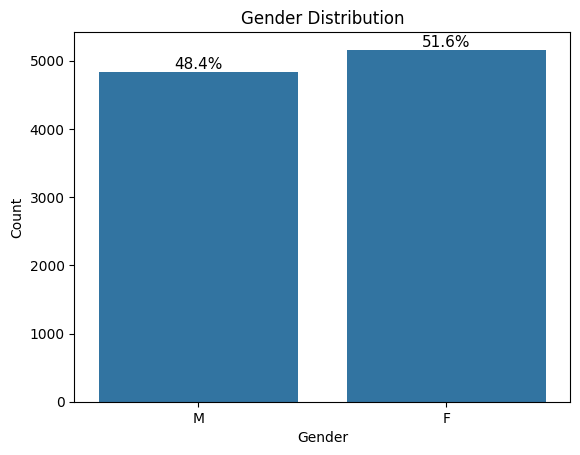

In [18]:
# Customers Distribution by Age

# Countplot
plt.figure()

ax = sns.countplot(x='gender_cd', data=customers)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

# total observations
total = len(customers)

# annotate percentage
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11
    )

male = (customers['gender_cd'] == 'M').sum()
female = (customers['gender_cd'] == 'F').sum()

print("Total customers:", total)
print("Male customers:", male)
print("Female customers:", female)

plt.show()

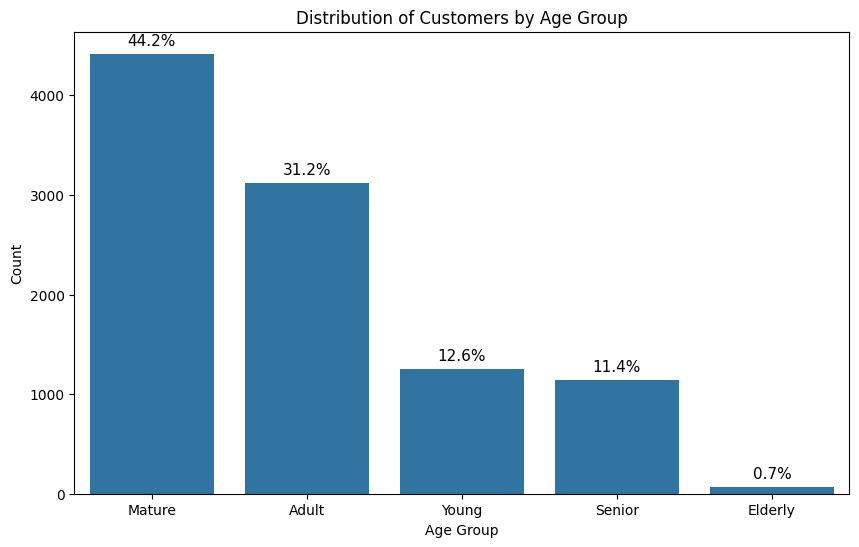

Total customers: 10000
age_group
Mature     4418
Adult      3118
Young      1257
Senior     1140
Elderly      67
Name: count, dtype: int64


In [19]:
# fixed reference date for reproducibility
REFERENCE_DATE = pd.Timestamp('2026-01-01')

#calculate the age

customers['birth_dt'] = pd.to_datetime(customers['birth_dt'])

customers['age'] = (
    (REFERENCE_DATE - customers['birth_dt']).dt.days / 365.25
).astype(int)


#grouping age

customers['age_group'] = pd.cut(
    customers['age'],
    bins=[0, 25, 40, 60, 80, 120],
    labels=['Young', 'Adult', 'Mature', 'Senior', 'Elderly']
)


plt.figure(figsize=(10, 6))
ax = sns.countplot(x='age_group', data=customers, order=customers['age_group'].value_counts().index)

plt.title("Distribution of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")


# total number of customers
total = len(customers)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(customers["age_group"].value_counts())


**The dataset represents age distribution of customers is mostly between 30 and 50 years old (the right skewed)**

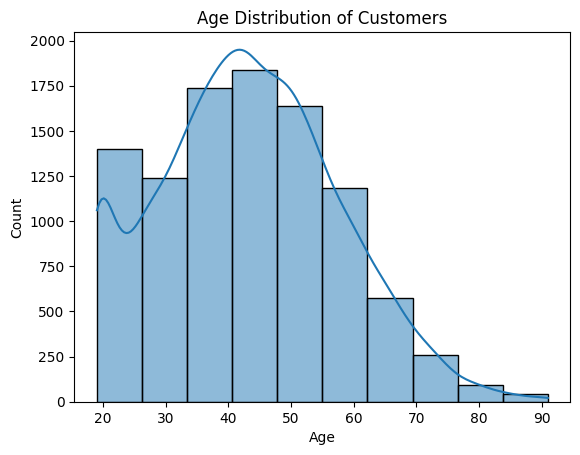

In [20]:
plt.figure()
sns.histplot(customers['age'], bins=10, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


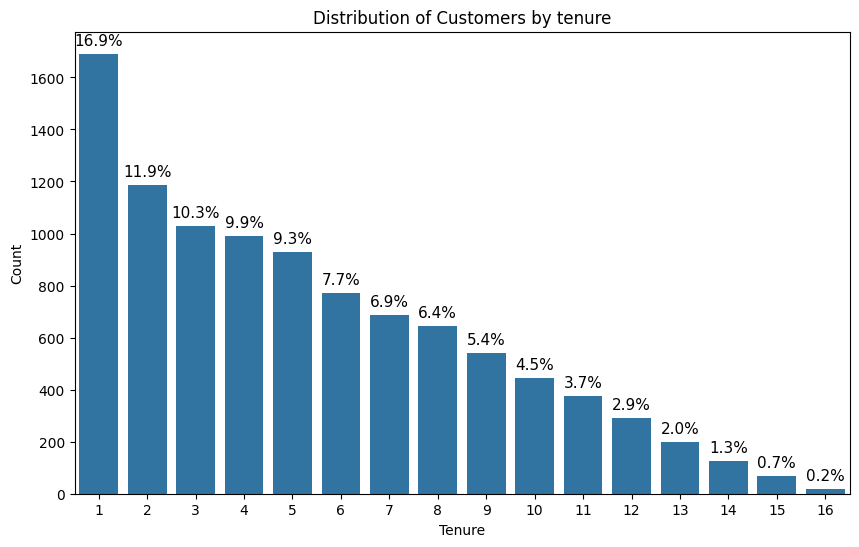

Total customers: 10000
tenure
1     1691
2     1188
3     1029
4      992
5      929
6      773
7      687
8      644
9      542
10     446
11     374
12     292
13     200
14     126
15      67
16      20
Name: count, dtype: int64


In [21]:
# fixed reference date for reproducibility

REFERENCE_DATE = pd.Timestamp('2026-01-01')

#calculate the age

customers['bank_reg_dt'] = pd.to_datetime(customers['bank_reg_dt'])

customers['tenure'] = (
    (REFERENCE_DATE - customers['bank_reg_dt']).dt.days / 365.25
).astype(int)


plt.figure(figsize=(10, 6))
ax = sns.countplot(x='tenure', data=customers, order=customers['tenure'].value_counts().index)

plt.title("Distribution of Customers by tenure")
plt.xlabel("Tenure")
plt.ylabel("Count")


# total number of customers
total = len(customers)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(customers["tenure"].value_counts())


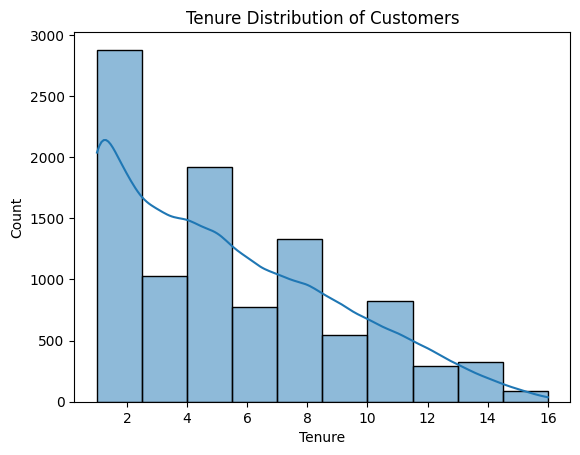

In [22]:
plt.figure()
sns.histplot(customers['tenure'], bins=10, kde=True)
plt.title('Tenure Distribution of Customers')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

**The dataset represents tenure distribution of customers is mostly around 2 years (right skewed)**

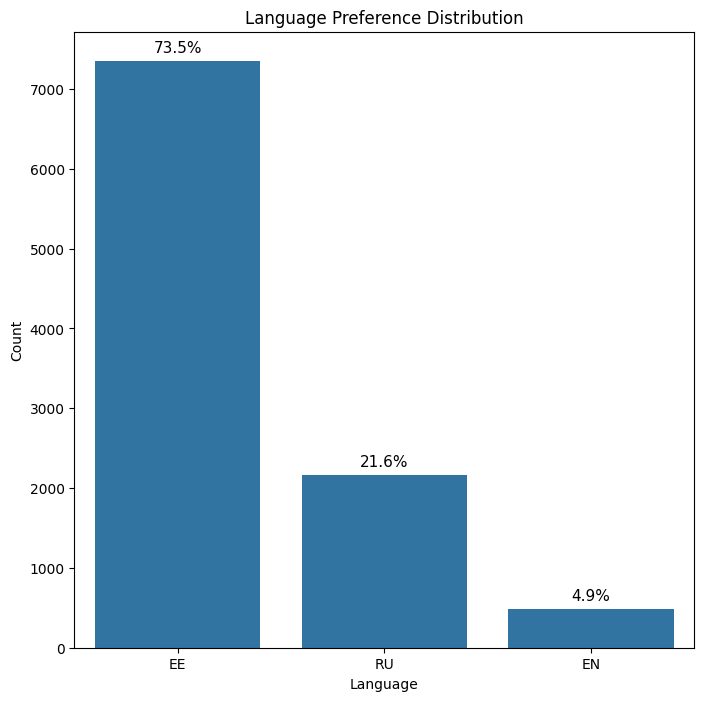

Total customers: 10000
lang_pref
EE    7350
RU    2164
EN     486
Name: count, dtype: int64


In [23]:
plt.figure(figsize=(8, 8))

ax = sns.countplot(x='lang_pref', data=customers, order=customers['lang_pref'].value_counts().index)
plt.title("Language Preference Distribution")
plt.xlabel("Language")
plt.ylabel("Count")


# total number of customers
total = len(customers)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(customers["lang_pref"].value_counts())

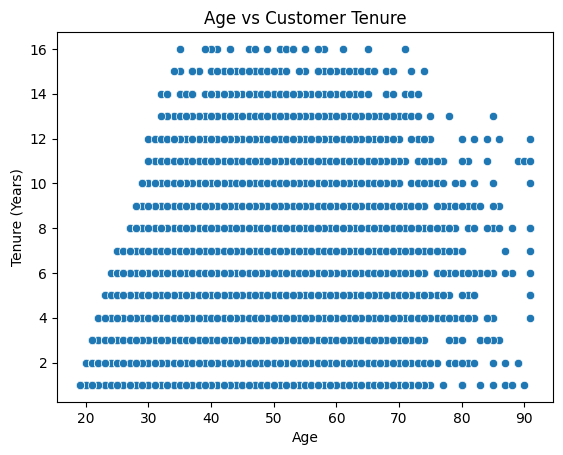

In [26]:
plt.figure()
sns.scatterplot(
    data=customers,
    x="age",
    y=customers["tenure"]
)
plt.title("Age vs Customer Tenure")
plt.xlabel("Age")
plt.ylabel("Tenure (Years)")
plt.show()


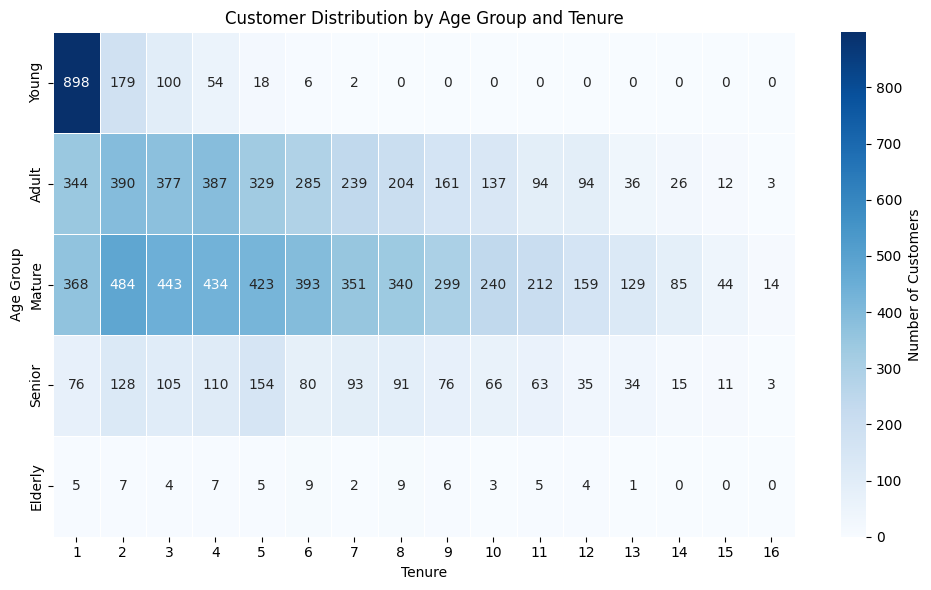

In [27]:
pivot = pd.pivot_table(
    customers,
    values="client_id",
    index="age_group",
    columns="tenure",
    aggfunc="count",
    fill_value=0
)


plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Number of Customers"}
)

plt.title("Customer Distribution by Age Group and Tenure")
plt.xlabel("Tenure")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

### **Data Dictionary for Margin Assets Table**

| Field                 | Description                               |
| --------------------- | ----------------------------------------- |
| acct_ccy              | Account currency                          |
| avg_balance_eur       | Average balance across the month          |
| avg_interest_base_eur | Average balance used for interest accrual |
| client_id_fk          | Foreign key to `customers.client_id`      |
| end_balance_eur       | Balance at month end (EUR)                |
| month_end             | Month-end snapshot date                   |




In [28]:
# accessing dataframe margin_assets

margin_assets = dataframes['margin_assets']

margin_assets.head()

,acct_ccy,avg_balance_eur,avg_interest_base_eur,client_id_fk,end_balance_eur,month_end
0,EUR,6378.58,6100.54,CUST000007,6433.63,2024-01-31
1,EUR,6485.76,4694.14,CUST000007,6221.45,2024-02-29
2,EUR,4843.42,3558.95,CUST000007,4951.52,2024-03-31
3,EUR,6292.46,5926.30,CUST000007,7147.96,2024-04-30
4,EUR,4846.27,3611.47,CUST000007,4760.32,2024-05-31


### **Data Dictionary for Margin Liabilities Table**

| Field                 | Description                               |
| --------------------- | ----------------------------------------- |
| avg_balance_eur       | Average balance across the month          |
| avg_interest_base_eur | Average balance used for interest accrual |
| client_id_fk          | Foreign key to `customers.client_id`      |
| contract_ccy          | Agreement currency                        |
| end_balance_eur       | Balance at month end (EUR)                |
| month_end             | Month-end snapshot date                   |


In [29]:
# accessing dataframe margin_liabilities
margin_liabilities = dataframes['margin_liabilities']

margin_liabilities.head()

,avg_balance_eur,avg_interest_base_eur,client_id_fk,contract_ccy,end_balance_eur,month_end
0,4339.59,3797.14,CUST000002,EUR,3944.13,2024-01-31
1,4244.11,3489.67,CUST000002,EUR,4094.33,2024-02-29
2,4190.52,4054.46,CUST000002,EUR,4077.30,2024-03-31
3,3953.78,3678.45,CUST000002,EUR,3864.00,2024-04-30
4,4148.58,3939.64,CUST000002,EUR,3532.76,2024-05-31


# **Financial Capacity Profiles (Assets & Liabilities)**

### - **Basic Data Information Customers' Financial Capacity**


**To construct the financial capacity profile, customer-level balances are aggregated over a 12-month observation window. Customers are categorized based on the presence of asset and liability balances into deposit-only, loan-only, both, or inactive (if any) groups. Average annual balances are used to represent typical financial capacity, reducing sensitivity to short-term fluctuations.**

In [30]:
margin_assets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31908 entries, 0 to 31907
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   acct_ccy               31908 non-null  object 
 1   avg_balance_eur        31908 non-null  float64
 2   avg_interest_base_eur  31908 non-null  float64
 3   client_id_fk           31908 non-null  object 
 4   end_balance_eur        31908 non-null  float64
 5   month_end              31908 non-null  object 
dtypes: float64(3), object(3)
memory usage: 1.5+ MB


In [31]:
margin_liabilities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22839 entries, 0 to 22838
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   avg_balance_eur        22839 non-null  float64
 1   avg_interest_base_eur  22839 non-null  float64
 2   client_id_fk           22839 non-null  object 
 3   contract_ccy           22839 non-null  object 
 4   end_balance_eur        22839 non-null  float64
 5   month_end              22839 non-null  object 
dtypes: float64(3), object(3)
memory usage: 1.0+ MB


In [32]:
print("liabilities:", margin_liabilities.shape)
print("assets:", margin_assets.shape)

liabilities: (22839, 6)
assets: (31908, 6)


### - **Aggregate margin_assets**

In [33]:
#copy dataframe
ma = margin_assets.copy()

# change feature name to client_id
ma = ma.rename(columns={"client_id_fk": "client_id"})

# change the date type of month_end
if "month_end" in ma.columns:
    ma["month_end"] = pd.to_datetime(ma["month_end"], errors="coerce")

print('client_id empty:', ma["client_id"].isna().sum())

ma.head()


client_id empty: 0


,acct_ccy,avg_balance_eur,avg_interest_base_eur,client_id,end_balance_eur,month_end
0,EUR,6378.58,6100.54,CUST000007,6433.63,2024-01-31
1,EUR,6485.76,4694.14,CUST000007,6221.45,2024-02-29
2,EUR,4843.42,3558.95,CUST000007,4951.52,2024-03-31
3,EUR,6292.46,5926.30,CUST000007,7147.96,2024-04-30
4,EUR,4846.27,3611.47,CUST000007,4760.32,2024-05-31


In [34]:
# aggregation per customer id

# ma.groupby("client_id").dropna(...)

# ma.dropna(subset=["client_id"]).groupby("client_id").agg(...)


assets_profile = (
    ma.dropna(subset=["client_id"])
      .groupby("client_id", as_index=False)
      .agg(
          asset_months_present=("month_end", lambda s: s.dt.to_period("M").nunique() if s.notna().any() else 0),
          avg_assets_balance_eur=("avg_balance_eur", "mean"),
          end_assets_balance_eur=("end_balance_eur", "mean"),
      )
)

assets_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur
0,CUST000007,12,5532.411667,5617.427500
1,CUST000009,12,1319.543333,1255.741667
2,CUST000012,12,4518.456667,4404.460833
3,CUST000028,12,3173.767500,3263.986667
4,CUST000029,12,26067.799167,26056.237500


### - **Aggregate margin_liabilities**

In [35]:
#copy dataframe
ml = margin_liabilities.copy()

# change feature name to client_id
ml = ml.rename(columns={"client_id_fk": "client_id"})

# change the date type of month_end
if "month_end" in ml.columns:
    ml["month_end"] = pd.to_datetime(ml["month_end"], errors="coerce")

print('client_id empty:', ml["client_id"].isna().sum())

ml.head()

client_id empty: 0


,avg_balance_eur,avg_interest_base_eur,client_id,contract_ccy,end_balance_eur,month_end
0,4339.59,3797.14,CUST000002,EUR,3944.13,2024-01-31
1,4244.11,3489.67,CUST000002,EUR,4094.33,2024-02-29
2,4190.52,4054.46,CUST000002,EUR,4077.30,2024-03-31
3,3953.78,3678.45,CUST000002,EUR,3864.00,2024-04-30
4,4148.58,3939.64,CUST000002,EUR,3532.76,2024-05-31


In [36]:
# aggregation per customer id

# ma.groupby("client_id").dropna(...)

# ma.dropna(subset=["client_id"]).groupby("client_id").agg(...)


liabilities_profile = (
    ml.dropna(subset=["client_id"])
      .groupby("client_id", as_index=False)
      .agg(
          liabilities_months_present=("month_end", lambda s: s.dt.to_period("M").nunique() if s.notna().any() else 0),
          avg_liabilities_balance_eur=("avg_balance_eur", "mean"),
          end_liabilities_balance_eur=("end_balance_eur", "mean"),
      )
)

liabilities_profile.head()


,client_id,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur
0,CUST000002,12,3816.380000,3662.404167
1,CUST000003,12,5413.245833,5461.457500
2,CUST000006,12,21866.440833,22202.955833
3,CUST000011,12,2110.405833,2102.321667
4,CUST000012,12,6509.881667,6419.411667


### - **Customer Baseline table**

In [37]:
cb = customers.copy()

# aligning customer id column name
cb = cb.rename(columns={"client_id": "client_id"})

customer_base = cb[["client_id"]].drop_duplicates()
customer_base.head()


,client_id
0,CUST000001
1,CUST000002
2,CUST000003
3,CUST000004
4,CUST000005


### - **Customer Baseline table join with Financial baseline**

In [38]:
# join customer baseline with financial baseline (assets & liabilities)

financial_profile = (
    customer_base
    .merge(assets_profile, on="client_id", how="left")
    .merge(liabilities_profile, on="client_id", how="left")
)

financial_profile.head()


,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur
0,CUST000001,NaN,NaN,NaN,NaN,NaN,NaN
1,CUST000002,NaN,NaN,NaN,12.0,3816.380000,3662.404167
2,CUST000003,NaN,NaN,NaN,12.0,5413.245833,5461.457500
3,CUST000004,NaN,NaN,NaN,NaN,NaN,NaN
4,CUST000005,NaN,NaN,NaN,NaN,NaN,NaN


### - **Fill row (NaN) with 0**

In [39]:
cols_to_fill = [
    "asset_months_present",
    "avg_assets_balance_eur",
    "end_assets_balance_eur",
    "liabilities_months_present",
    "avg_liabilities_balance_eur",
    "end_liabilities_balance_eur",
]

for c in cols_to_fill:
    financial_profile[c] = financial_profile[c].fillna(0)

financial_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur
0,CUST000001,0.0,0.0,0.0,0.0,0.000000,0.000000
1,CUST000002,0.0,0.0,0.0,12.0,3816.380000,3662.404167
2,CUST000003,0.0,0.0,0.0,12.0,5413.245833,5461.457500
3,CUST000004,0.0,0.0,0.0,0.0,0.000000,0.000000
4,CUST000005,0.0,0.0,0.0,0.0,0.000000,0.000000


### - **Assign financial type label**


**Logic:**

assets > 0 & liabilities = 0 -> deposit_only

assets = 0 & liabilities > 0 -> loan_only

assets > 0 & liabilities > 0 -> both

assets = 0 & liabilities = 0 -> inactive

In [40]:
# add labelling

financial_profile["has_assets"] = financial_profile["avg_assets_balance_eur"] > 0
financial_profile["has_liabilities"] = financial_profile["avg_liabilities_balance_eur"] > 0

financial_profile["financial_type"] = np.select(
    [
        financial_profile["has_assets"] & ~financial_profile["has_liabilities"],
        ~financial_profile["has_assets"] & financial_profile["has_liabilities"],
        financial_profile["has_assets"] & financial_profile["has_liabilities"],
    ],
    ["deposit_only", "loan_only", "both"],
    default="inactive"
)

financial_profile[["client_id","avg_assets_balance_eur","avg_liabilities_balance_eur","financial_type"]].head(10)


,client_id,avg_assets_balance_eur,avg_liabilities_balance_eur,financial_type
0,CUST000001,0.000000,0.000000,inactive
1,CUST000002,0.000000,3816.380000,loan_only
2,CUST000003,0.000000,5413.245833,loan_only
3,CUST000004,0.000000,0.000000,inactive
4,CUST000005,0.000000,0.000000,inactive
5,CUST000006,0.000000,21866.440833,loan_only
6,CUST000007,5532.411667,0.000000,deposit_only
7,CUST000008,0.000000,0.000000,inactive
8,CUST000009,1319.543333,0.000000,deposit_only
9,CUST000010,0.000000,0.000000,inactive


In [41]:
# change the key column to adjust and align the name in all tables
for df, col in [(customers, "client_id"), (margin_assets, "client_id_fk"), (margin_liabilities, "client_id_fk")]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# check if there is overlap id assets vs customers
cust_ids = set(customers["client_id"].astype(str).str.strip().unique())
asset_ids = set(margin_assets["client_id_fk"].astype(str).str.strip().unique())
liab_ids  = set(margin_liabilities["client_id_fk"].astype(str).str.strip().unique())

print("customers:", len(cust_ids))
print("assets ids:", len(asset_ids), "overlap with customers:", len(cust_ids & asset_ids))
print("liab ids:", len(liab_ids), "overlap with customers:", len(cust_ids & liab_ids))

# To print client_id in the assets but not in customers tables
print("sample assets-only ids:", list(asset_ids - cust_ids)[:10])


customers: 10000
assets ids: 2659 overlap with customers: 2659
liab ids: 1929 overlap with customers: 1929
sample assets-only ids: []


In [42]:
#Checking the financial type distributions
financial_profile["financial_type"].value_counts(dropna=False)

financial_type
inactive        5957
deposit_only    2114
loan_only       1384
both             545
Name: count, dtype: int64

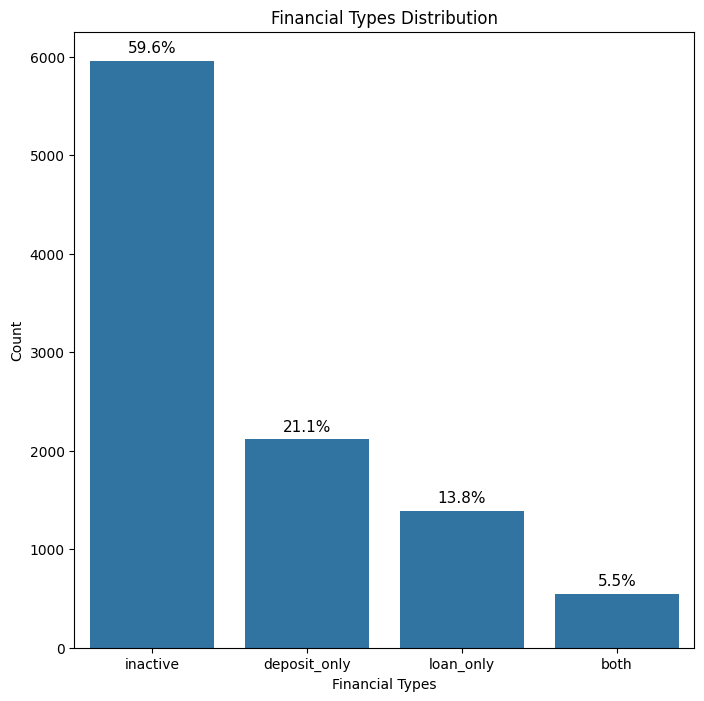

Total customers: 10000
financial_type
inactive        5957
deposit_only    2114
loan_only       1384
both             545
Name: count, dtype: int64


In [43]:
plt.figure(figsize=(8, 8))

ax = sns.countplot(x='financial_type', data=financial_profile, order=financial_profile["financial_type"].value_counts(dropna=False).index)
plt.title("Financial Types Distribution")
plt.xlabel("Financial Types")
plt.ylabel("Count")

# total number of each financial type
total = len(financial_profile)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(financial_profile["financial_type"].value_counts())

In [44]:
financial_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur,has_assets,has_liabilities,financial_type
0,CUST000001,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive
1,CUST000002,0.0,0.0,0.0,12.0,3816.380000,3662.404167,False,True,loan_only
2,CUST000003,0.0,0.0,0.0,12.0,5413.245833,5461.457500,False,True,loan_only
3,CUST000004,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive
4,CUST000005,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive


### - **Financial Exposure Ratio**

A Financial Exposure Ratio is constructed as the ratio between average observed liabilities and average observed assets. The indicator does not represent a regulatory leverage or capital metric, but serves as a relative exposure proxy to contextualize the potential impact of transaction-level anomalies on customers’ financial capacity. Not all customers hold both deposit and liability products; therefore, margin asset and margin liability tables cover only subsets of the customer population. Missing balances are interpreted as absence of observed exposure and are treated as zero for exposure profiling.


In [45]:
financial_profile["financial_exposure_ratio"] = np.where(
    financial_profile["avg_assets_balance_eur"] > 0,
    financial_profile["avg_liabilities_balance_eur"] / financial_profile["avg_assets_balance_eur"],
    np.nan
)


In [46]:
financial_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur,has_assets,has_liabilities,financial_type,financial_exposure_ratio
0,CUST000001,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN
1,CUST000002,0.0,0.0,0.0,12.0,3816.380000,3662.404167,False,True,loan_only,NaN
2,CUST000003,0.0,0.0,0.0,12.0,5413.245833,5461.457500,False,True,loan_only,NaN
3,CUST000004,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN
4,CUST000005,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN


### - **Interpretation of the Financial Exposure Ratio**


| Asset (Buffer) Condition | Liability (Exposure) Condition | Ratio Value     | Plain Meaning                                                                                                                                           |
| ------------------------ | ------------------------------ | --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Present (> 0)            | Present (> 0)                  | > 0             | The customer has both financial obligations and observable buffers. The ratio indicates the relative size of obligations compared to available buffers. |
| Present (> 0)            | Absent (= 0)                   | 0               | The customer has observable buffers and no financial obligations. There is no exposure pressure from liabilities.                                       |
| Absent (= 0)             | Present (> 0)                  | NaN (undefined) | No observable buffer is available, therefore the ratio cannot be meaningfully calculated. This is not a data error.                                     |
| Absent (= 0)             | Absent (= 0)                   | NaN (undefined) | Neither buffers nor obligations are observed. The ratio has no valid reference point for calculation.                                                   |


### **Interpretation Notes**

1. NaN indicates an undefined ratio due to missing reference information, not a low or high risk level.

2. The ratio is used to contextualize financial exposure, not to assess credit risk or regulatory leverage.

3. Results are interpreted relatively, rather than against fixed thresholds.


In [47]:
(financial_profile["avg_assets_balance_eur"] > 0).value_counts()

avg_assets_balance_eur
False    7341
True     2659
Name: count, dtype: int64

In [48]:
financial_profile["avg_assets_balance_eur"].describe()

count    10000.000000
mean      1326.864019
std       3574.167365
min          0.000000
25%          0.000000
50%          0.000000
75%        692.102917
max      61705.510833
Name: avg_assets_balance_eur, dtype: float64

In [50]:
(financial_profile["avg_liabilities_balance_eur"] > 0).value_counts()

avg_liabilities_balance_eur
False    8071
True     1929
Name: count, dtype: int64

In [51]:
financial_profile["avg_liabilities_balance_eur"].describe()

count     10000.000000
mean       1515.340558
std        5583.234201
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      135321.409167
Name: avg_liabilities_balance_eur, dtype: float64

In [52]:
financial_profile.loc[
    financial_profile["avg_assets_balance_eur"] > 0,
    ["client_id", "avg_assets_balance_eur", "avg_liabilities_balance_eur"]
].head()

,client_id,avg_assets_balance_eur,avg_liabilities_balance_eur
6,CUST000007,5532.411667,0.000000
8,CUST000009,1319.543333,0.000000
11,CUST000012,4518.456667,6509.881667
27,CUST000028,3173.767500,0.000000
28,CUST000029,26067.799167,0.000000


### - **Valid Ratio Distribution**

In [53]:
financial_profile["asset_present"] = financial_profile["avg_assets_balance_eur"] > 0
financial_profile["liability_present"] = financial_profile["avg_liabilities_balance_eur"] > 0

In [54]:
pd.crosstab(
    financial_profile["asset_present"],
    financial_profile["liability_present"],
    margins=True
)


liability_present,False,True,All
asset_present,,,
False,5957,1384,7341
True,2114,545,2659
All,8071,1929,10000


In [56]:
valid_ratio = financial_profile[
    (financial_profile["avg_assets_balance_eur"] > 0) &
    (financial_profile["avg_liabilities_balance_eur"] > 0)
]["financial_exposure_ratio"]


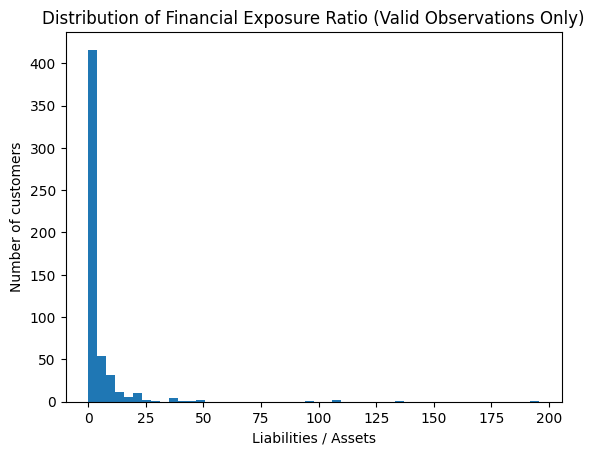

In [57]:
plt.hist(valid_ratio, bins=50)
plt.title("Distribution of Financial Exposure Ratio (Valid Observations Only)")
plt.xlabel("Liabilities / Assets")
plt.ylabel("Number of customers")
plt.show()


In [58]:
valid_ratio.describe()

count    545.000000
mean       4.814764
std       13.992942
min        0.013897
25%        0.485111
50%        1.440731
75%        3.681488
max      195.658633
Name: financial_exposure_ratio, dtype: float64

### - **Ratio vs Asset Presence**

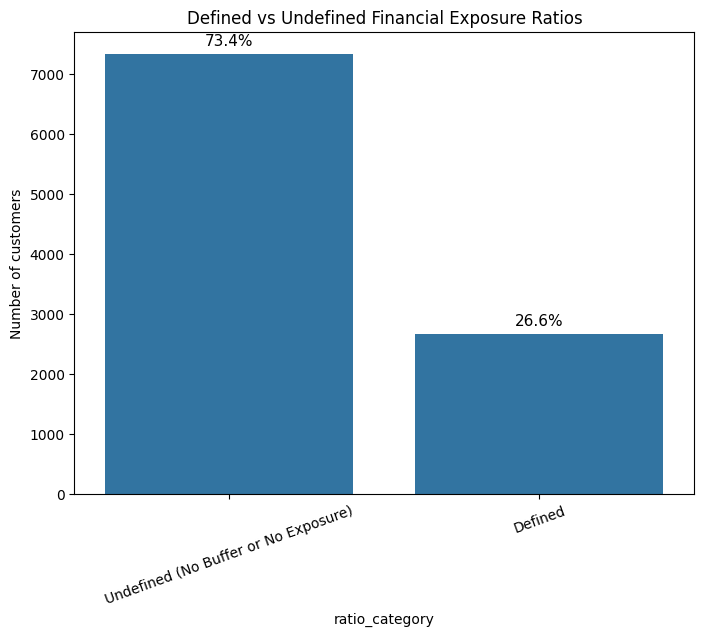

Total customers: 10000
ratio_category
Undefined (No Buffer or No Exposure)    7341
Defined                                 2659
Name: count, dtype: int64


In [88]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='ratio_category', data=financial_profile, order=financial_profile["ratio_category"].value_counts(dropna=False).index)
plt.title("Defined vs Undefined Financial Exposure Ratios")
plt.ylabel("Number of customers")
plt.xticks(rotation=20)

# total number of each financial type
total = len(financial_profile)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(financial_profile["ratio_category"].value_counts())


**The distribution of customer financial exposure statuses is based on the presence of observable assets and liabilities. A significant number of customers have undefined financial exposure ratios due to the absence of either buffers or obligations. These undefined values represent structurally non-computable cases, rather than issues with data quality. Therefore, they are retained for contextual interpretation instead of being imputed.

### - **Data Dictionary for Transactions 2024 Table**

| Field             | Description                                                        |
| ----------------- | ------------------------------------------------------------------ |
| acct_iban         | IBAN of the customer’s account                                     |
| amount_eur        | Transaction amount converted to EUR                                |
| amount_orig       | Amount in the original transaction currency                        |
| date              | Value / booking date of the transaction (bank ledger date)         |
| time              | Time component for the booking entry                               |
| channel           | Origin channel: online, mobile, card, branch, atm                  |
| client_id         | Foreign key to `customers.client_id`                               |
| counterparty_iban | IBAN of the other party                                            |
| day_in_month      | Day component (01–31) from booking date                            |
| d_c               | **Codes:** D = debit (money leaves); C = credit (money enters)     |
| mcc               | 4-digit merchant category code (ISO 18245); card transactions only |
| merchant_country  | Country of the merchant (card transactions only)                   |
| period_yy_mm      | Two-digit year + two-digit month from booking date                 |
| trx_ccy           | Original transaction currency                                      |
| txn_id            | Unique transaction / journal identifier                            |
| weekday_name      | Three-letter day name (Sun–Sat)                                    |






## **Transactions Profile**

### - **Basic Data Information Transactions**

In [61]:
# accessing dataframe transactions_2024
transactions_2024 = dataframes['transactions_2024']

transactions_2024.head()

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE
1,CUST000001,2024-01-12,13:32:11,TX00000002,online,D,EUR,88.83,88.83,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BEF6GRNF2ANPJCRMF5CIJI3W,NaN,EE
2,CUST000001,2024-01-22,18:37:34,TX00000003,card,D,EUR,11.79,11.79,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_2NPYIVWYTU6RB3EF2DPW5K2T,5816.0,EE
3,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE
4,CUST000001,2024-02-12,23:50:31,TX00000005,online,D,EUR,95.47,95.47,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BXJ2CJNGBHCMPJURBIU7RSLX,NaN,EE


In [62]:
#Checking & Handing Missing Values

# check NA in each row
nan_rows = transactions_2024.isna().any(axis=1)
print("NA in rows information:")
display(nan_rows)

#check how many NA value in each row
nan_rows_sum = transactions_2024.isnull().sum().sort_values(ascending=False)
print(" ")
print("NA value in rows (Sum):")
display(nan_rows_sum)

NA in rows information:


0           True
1           True
2          False
3           True
4           True
           ...  
1551063     True
1551064     True
1551065     True
1551066     True
1551067     True
Length: 1551068, dtype: bool

 
NA value in rows (Sum):


mcc                  652354
client_id                 0
date                      0
time                      0
txn_id                    0
channel                   0
d_c                       0
trx_ccy                   0
amount_eur                0
amount_orig               0
acct_iban                 0
counterparty_iban         0
merchant_country          0
dtype: int64

**There is no empty rows in all features**

In [63]:
transactions_2024.shape

(1551068, 13)

In [64]:
# Descriptive statistics for numerical
transactions_2024.describe(include= [np.number])

,amount_eur,amount_orig,mcc
count,1.551068e+06,1.551068e+06,898714.000000
mean,1.720244e+02,1.879295e+02,5548.715851
std,4.634241e+02,5.406237e+02,622.744620
min,6.000000e-01,6.000000e-01,4111.000000
25%,1.980000e+01,2.009000e+01,5411.000000
50%,3.960000e+01,4.083000e+01,5651.000000
75%,8.863000e+01,9.485000e+01,5816.000000
max,7.199460e+03,6.549389e+04,7999.000000


In [65]:
# Descriptive statistics for non-numerical
transactions_2024.describe(include='object')

,client_id,date,time,txn_id,channel,d_c,trx_ccy,acct_iban,counterparty_iban,merchant_country
count,1551068,1551068,1551068,1551068,1551068,1551068,1551068,1551068,1551068,1551068
unique,9519,366,64730,1551068,5,2,9,13664,14975,17
top,CUST009523,2024-12-16,15:30:55,TX00000001,card,D,EUR,ACC_MWMZ7HOPJ4TPFNQNCZSKS6GG,CP_Z77UW3O3C3Q5VUFKDXQTASEI,EE
freq,724,12413,68,1,898714,1359488,1508379,719,59962,1391364


In [66]:
transactions_2024.columns

Index(['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy',
       'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc',
       'merchant_country'],
      dtype='object')

### - **Checking & Handing Missing Values**

In [67]:
# check NA in each row

nan_rows = transactions_2024.isna().any(axis=1)
print("NA in rows information:")
display(nan_rows)

NA in rows information:


0           True
1           True
2          False
3           True
4           True
           ...  
1551063     True
1551064     True
1551065     True
1551066     True
1551067     True
Length: 1551068, dtype: bool

In [68]:
#check how many NA value in each row
nan_rows_sum = transactions_2024.isnull().sum().sort_values(ascending=False)
print(" ")
print("NA value in rows (Sum):")
display(nan_rows_sum)

 
NA value in rows (Sum):


mcc                  652354
client_id                 0
date                      0
time                      0
txn_id                    0
channel                   0
d_c                       0
trx_ccy                   0
amount_eur                0
amount_orig               0
acct_iban                 0
counterparty_iban         0
merchant_country          0
dtype: int64

**There is no empty rows in all features**

In [71]:
transactions_2024["amount_eur"].describe()

count    1.551068e+06
mean     1.720244e+02
std      4.634241e+02
min      6.000000e-01
25%      1.980000e+01
50%      3.960000e+01
75%      8.863000e+01
max      7.199460e+03
Name: amount_eur, dtype: float64

### - **Check Transaction Distribution**

The dataset represents a structurally homogeneous customer segment, where variation is primarily driven by demographic and lifecycle attributes rather than organisational or product complexity.


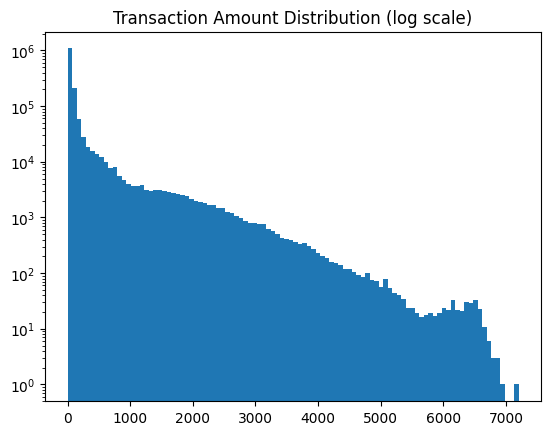

In [73]:
plt.hist(transactions_2024["amount_eur"], bins=100)
plt.yscale("log")
plt.title("Transaction Amount Distribution (log scale)")
plt.show()


### - **Transaction Channel Distribution**

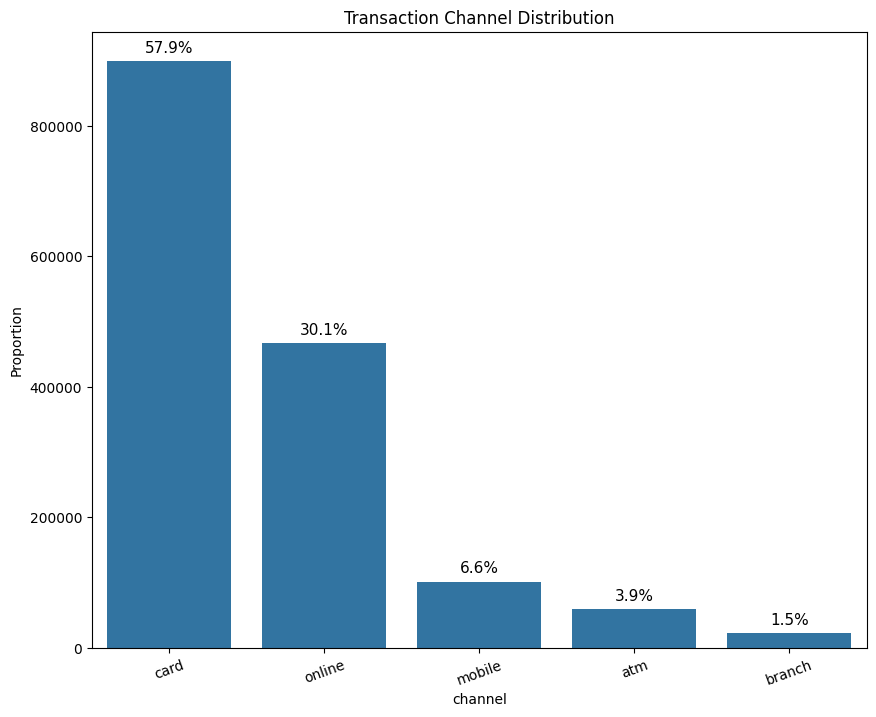

Total proportion per Channel: 1551068
channel
card      898714
online    467489
mobile    101835
atm        59962
branch     23068
Name: count, dtype: int64


In [91]:
plt.figure(figsize=(10, 8))

ax = sns.countplot(x='channel', data=transactions_2024, order=transactions_2024["channel"].value_counts(dropna=False).index)
plt.title("Transaction Channel Distribution")
plt.ylabel("Proportion")
plt.xticks(rotation=20)

# total number of each financial type
total = len(transactions_2024)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total proportion per Channel:", len(transactions_2024))
print(transactions_2024["channel"].value_counts())



### - **Debit vs Credit Distribution**

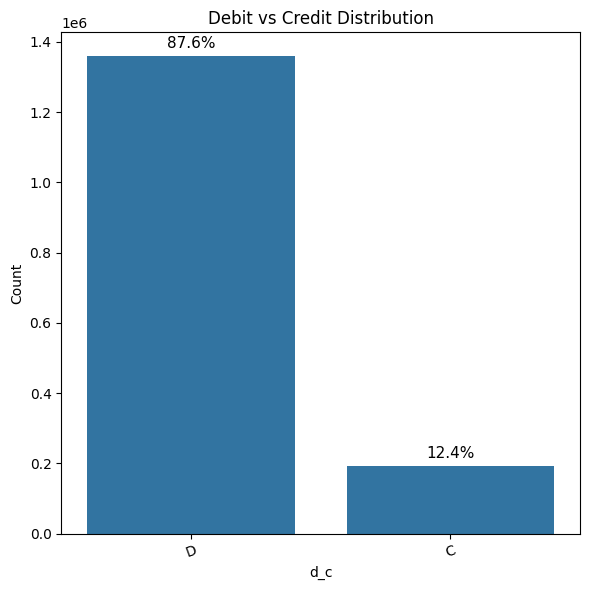

Total transactions: 1551068
d_c
D    1359488
C     191580
Name: count, dtype: int64

Proportion:
d_c
D    0.8765
C    0.1235
Name: proportion, dtype: float64


In [95]:
plt.figure(figsize=(6, 6))

ax = sns.countplot(
    x="d_c",
    data=transactions_2024,
    order=transactions_2024["d_c"].value_counts().index
)

plt.title("Debit vs Credit Distribution")
plt.xlabel("d_c")
plt.ylabel("Count")
plt.xticks(rotation=20)

total = len(transactions_2024)

for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total if total > 0 else 0
    ax.annotate(
        f"{percentage:.1f}%",
        (p.get_x() + p.get_width() / 2., count),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

print("Total transactions:", len(transactions_2024))
print(transactions_2024["d_c"].value_counts())
print("\nProportion:")
print(transactions_2024["d_c"].value_counts(normalize=True).round(4))


### - **Date and Time (For Checking Transaction Velocity-Cleaning Data Only)**

In [96]:
transactions_2024.columns

Index(['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy',
       'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc',
       'merchant_country'],
      dtype='object')

In [97]:
transactions = transactions_2024.copy()

# date: wajib jadi datetime biar bisa rolling dan sort
transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")

### - **Customer-Day (Customer Transaction Per Day)**

In [98]:
customer_day = (
    transactions
    .dropna(subset=["client_id", "date"])
    .groupby(["client_id", "date"], as_index=False)
    .agg(
        daily_txn_count=("txn_id", "count"),
        daily_total_amount=("amount_eur", "sum"),
        daily_avg_amount=("amount_eur", "mean")
    )
)

customer_day.head()


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount
0,CUST000001,2024-01-12,1,88.83,88.830
1,CUST000001,2024-01-15,1,37.68,37.680
2,CUST000001,2024-01-16,1,28.32,28.320
3,CUST000001,2024-01-19,1,57.14,57.140
4,CUST000001,2024-01-22,2,105.37,52.685


### - **Customer-Day Sorting (Customer Transaction Per Day)**

In [99]:
customer_day = customer_day.sort_values(
    ["client_id", "date"]
).reset_index(drop=True)

customer_day.head()


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount
0,CUST000001,2024-01-12,1,88.83,88.830
1,CUST000001,2024-01-15,1,37.68,37.680
2,CUST000001,2024-01-16,1,28.32,28.320
3,CUST000001,2024-01-19,1,57.14,57.140
4,CUST000001,2024-01-22,2,105.37,52.685


### - **Customer Transaction Identification: customers' unstable transaction activities**

This step aims to validate if there is customers with unstable transaction as the illustration given above related to **``Illustrative Examples: Application of Tolerance Margins at the Customer Level``**.

By applying **Coefficient of Variation (CV)** we will measure how customer transaction activities "spread out" in the data relative to its average to find if there is customers' unstable transaction activities. The purpose of this step is not to classify risk, but to validate the existence of customers whose transaction behavior naturally exhibits higher variability, which is an important consideration when defining baseline assumptions and tolerance margins.

To assess transaction stability at the customer level, the Coefficient of Variation (CV) is applied to customer-specific transaction metrics. The CV measures how dispersed transaction activity is relative to its average level, allowing the identification of customers whose behavior fluctuates substantially over time.

The Coefficient of Variation is calculated as:

$$CV = \left( \frac{\sigma}{\mu} \right) \times 100$$


where

$\sigma$ represents the standard deviation of a customer’s transaction activity, and

$\mu$ represents the mean of that activity.


**Why Using CV?** 

CV allows to compare the "volatility" or "instability" of two groups that have totally different units or scales. In some contexts, the CV may be expressed as a percentage by multiplying the ratio by 100; however, in this study the ratio form is sufficient for comparative purposes.


The CV is particularly suitable for this analysis because it enables the comparison of behavioral variability across customers, even when customers differ significantly in transaction frequency or transaction magnitude. Unlike absolute measures, the CV captures relative instability, making it appropriate for identifying customers whose transaction patterns are less consistent over time.

**In the context of this study, the CV supports three relevant analytical objectives:**

- Comparing different scales: Customers may have very different transaction volumes or frequencies, yet still be comparable in terms of relative variability.

- Assessing behavioral consistency: Higher CV values indicate less stable transaction behavior, which is relevant when evaluating baseline formation and tolerance margins.

- Supporting methodological validation: Identifying unstable customers allows the robustness of baseline assumptions (e.g., minimum observation requirements) to be evaluated under non-ideal, real-world conditions.

This step therefore provides an empirical foundation for later methodological choices, such as the selection of baseline parameters, without introducing additional complexity into the labeling or governance framework.


In [102]:
cv_per_customer = (
    customer_day
    .groupby("client_id")["daily_txn_count"]
    .agg(["mean", "std"])
)

cv_per_customer["cv"] = cv_per_customer["std"] / cv_per_customer["mean"]


In [103]:
cv_per_customer.head()

,mean,std,cv
client_id,,,
CUST000001,1.080000,0.273120,0.252889
CUST000002,1.000000,0.000000,0.000000
CUST000003,1.241176,0.505073,0.406931
CUST000004,1.116279,0.357067,0.319872
CUST000005,1.333333,0.577350,0.433013


In [104]:
unstable_customers = cv_per_customer["cv"].quantile(0.75)
unstable_customers


0.43922408404800495

### **Identification of Customers with Irregular Transaction Patterns**

The identified unstable customer exhibits a **Coefficient of Variation (CV) of 0.439**, indicating that the customer’s transaction activity varies by approximately **44%** relative to its average level. This level of variability reflects an irregular but plausible transaction pattern, rather than extreme or anomalous behavior.

**Transaction Pattern Categories:**
* **CV < 0.2**: Regular transaction behavior
* **CV 0.2 – 0.4**: Moderately variable transaction behavior
* **CV > 0.4**: Irregular transaction behavior

> **Note:** This categorization is used solely to distinguish levels of natural behavioral variability and does not represent a risk classification.

### **Calibration of the Minimum Observation Parameter (`min_periods`)**

The parameter defining the minimum number of historical observations (`min_periods`) in the expanding mean approach is calibrated using customers with irregular transaction behavior. This choice is intentional, as customers with higher variability make the trade-off between **baseline stability** and **responsiveness** more visible.

#### **Calibration Logic**
* **Stable Patterns:** For customers with stable transaction patterns, different values of `min_periods` tend to produce similar baseline behavior.
* **Irregular Patterns:** In contrast, for irregular customers, smaller values lead to overly reactive and noisy baselines, while larger values delay baseline formation.

As a result, irregular customers provide the most informative cases for evaluating **baseline robustness**.

#### **Implementation**
Although the calibration is informed by high-variability customers, the selected `min_periods` value is **applied uniformly** across the dataset. This ensures methodological simplicity while maintaining a conservative and robust global parameter suitable for the broader customer population.

### **Reference Customer (Irregular)**

In [105]:
# to get irregular customer as a stress case
ref_customer = (
    cv_per_customer
    .sort_values("cv", ascending=False)
    .index[0]
)

ref_customer


'CUST000723'

### **Customer-day of Reference Customer (Irregular)**

In [106]:
tmp = (
    customer_day
    .loc[customer_day["client_id"] == ref_customer]
    .sort_values("date")
    .copy()
)


In [107]:
tmp.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount
78184,CUST000723,2024-12-10,1,321.54,321.5400,NaN,NaN
78185,CUST000723,2024-12-11,2,44.76,22.3800,NaN,NaN
78186,CUST000723,2024-12-12,4,141.35,35.3375,NaN,NaN
78187,CUST000723,2024-12-14,1,30.18,30.1800,NaN,NaN
78188,CUST000723,2024-12-16,1,24.58,24.5800,1.8,112.482


### **Comparing ``min_periods`` value for Reference Customer (Irregular)**

> the comparation for finding ``min_periods``.

Candidate values of 3, 5, and 7 observations were selected to represent progressively increasing baseline stability requirements. These values are not chosen due to numerical parity, but to illustrate the trade-off between responsiveness and stability across meaningfully different minimum observation thresholds.

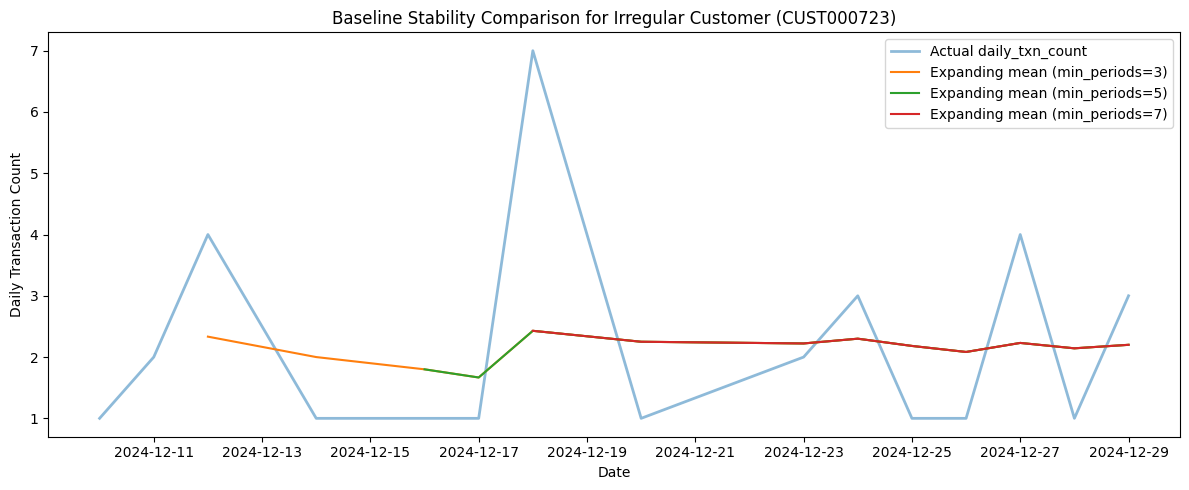

In [108]:
candidates = [3, 5, 7]

for m in candidates:
    tmp[f"baseline_txn_count_m{m}"] = (
        tmp["daily_txn_count"]
        .expanding(min_periods=m)
        .mean()
    )


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(tmp["date"], tmp["daily_txn_count"],
         label="Actual daily_txn_count", alpha=0.5, linewidth=2)

for m in candidates:
    plt.plot(
        tmp["date"],
        tmp[f"baseline_txn_count_m{m}"],
        label=f"Expanding mean (min_periods={m})"
    )

plt.title(f"Baseline Stability Comparison for Irregular Customer ({ref_customer})")
plt.xlabel("Date")
plt.ylabel("Daily Transaction Count")
plt.legend()
plt.tight_layout()
plt.show()



The graph illustrates the effect of different minimum observation requirements on baseline construction for a customer with irregular transaction behavior. When a small minimum threshold (min_periods = 3) is applied, the baseline becomes overly sensitive to short-term fluctuations, particularly during transaction spikes. Conversely, a larger threshold (min_periods = 7) results in delayed baseline formation and reduced coverage during the early observation period.

A minimum of five observations provides a balanced trade-off between stability and responsiveness. The resulting baseline smooths short-term volatility while remaining sufficiently adaptive to underlying behavioral changes. **This supports the selection of min_periods = 5 as a conservative and robust global parameter for baseline construction.**

### - **Customer Specific Baseline - Based on Transactions**

Baseline values are computed using an expanding mean approach with a minimum number of historical observations. This ensures that deviations are only assessed once sufficient customer-specific behavioral history is available, reducing noise and preventing premature labeling.

In [109]:
customer_day["baseline_txn_count"] = (
    customer_day
    .groupby("client_id")["daily_txn_count"]
    .transform(lambda s: s.expanding(min_periods=5).mean())
)

customer_day["baseline_total_amount"] = (
    customer_day
    .groupby("client_id")["daily_total_amount"]
    .transform(lambda s: s.expanding(min_periods=5).mean())
)


In [111]:
customer_day.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount
0,CUST000001,2024-01-12,1,88.83,88.830,NaN,NaN
1,CUST000001,2024-01-15,1,37.68,37.680,NaN,NaN
2,CUST000001,2024-01-16,1,28.32,28.320,NaN,NaN
3,CUST000001,2024-01-19,1,57.14,57.140,NaN,NaN
4,CUST000001,2024-01-22,2,105.37,52.685,1.2,63.468


**Explanation for NaN values in the customer baseline:**

As I mentioned above, the transaction observation uses an expanded mean with ``minimum period = 5``, so it means that in the first 4 recorded transaction histories, the data has not been labeled because the baseline is not yet stable, and we can see that in the fifth transaction history, the label has been given.

In [112]:
# to check basedline

customer_day[[
    "client_id", "date",
    "daily_txn_count", "baseline_txn_count",
    "daily_total_amount", "baseline_total_amount"
]].head(10)


,client_id,date,daily_txn_count,baseline_txn_count,daily_total_amount,baseline_total_amount
0,CUST000001,2024-01-12,1,NaN,88.83,NaN
1,CUST000001,2024-01-15,1,NaN,37.68,NaN
2,CUST000001,2024-01-16,1,NaN,28.32,NaN
3,CUST000001,2024-01-19,1,NaN,57.14,NaN
4,CUST000001,2024-01-22,2,1.200000,105.37,63.468000
5,CUST000001,2024-01-25,1,1.166667,1049.09,227.738333
6,CUST000001,2024-02-12,1,1.142857,95.47,208.842857
7,CUST000001,2024-02-16,1,1.125000,25.52,185.927500
8,CUST000001,2024-02-23,1,1.111111,994.77,275.798889
9,CUST000001,2024-03-02,1,1.100000,28.86,251.105000


### **Calculate Deviation Ratio**

In [113]:
customer_day["ratio_velocity"] = (
    customer_day["daily_txn_count"] /
    customer_day["baseline_txn_count"]
)

customer_day["ratio_value"] = (
    customer_day["daily_total_amount"] /
    customer_day["baseline_total_amount"]
)


In [115]:
customer_day.loc[
    customer_day["baseline_txn_count"] == 0,
    "ratio_velocity"
] = np.nan

customer_day.loc[
    customer_day["baseline_total_amount"] == 0,
    "ratio_value"
] = np.nan


In [116]:
customer_day[["client_id", "ratio_velocity", "ratio_value"]].head(10)

,client_id,ratio_velocity,ratio_value
0,CUST000001,NaN,NaN
1,CUST000001,NaN,NaN
2,CUST000001,NaN,NaN
3,CUST000001,NaN,NaN
4,CUST000001,1.666667,1.660207
5,CUST000001,0.857143,4.606559
6,CUST000001,0.875000,0.457138
7,CUST000001,0.888889,0.137258
8,CUST000001,0.900000,3.606867
9,CUST000001,0.909091,0.114932


### **Group deviation (Normal / Elevated / Significant)**

In [117]:
def deviation_group(r):
    if pd.isna(r):
        return np.nan
    elif r <= 1.2:
        return "Normal"
    elif r <= 2.0:
        return "Elevated"
    else:
        return "Significant"


customer_day["velocity_group"] = customer_day["ratio_velocity"].apply(deviation_group)
customer_day["value_group"] = customer_day["ratio_value"].apply(deviation_group)

customer_day[["velocity_group", "value_group"]].value_counts()

velocity_group  value_group
Normal          Normal         718664
Elevated        Normal         125369
Normal          Significant     95869
                Elevated        38575
Elevated        Significant     33529
                Elevated        19878
Significant     Normal          18892
                Significant     11181
                Elevated         7445
Name: count, dtype: int64

### **Map to suspiciousness label (Low / Medium / High)**

In [118]:
def map_suspiciousness(vg, ag):
    if vg == "Significant" or ag == "Significant":
        return "High"
    elif vg == "Elevated" or ag == "Elevated":
        return "Medium"
    elif vg == "Normal" and ag == "Normal":
        return "Low"
    else:
        return np.nan


customer_day["suspiciousness_label"] = customer_day.apply(
    lambda r: map_suspiciousness(
        r["velocity_group"], r["value_group"]
    ),
    axis=1
)

customer_day["suspiciousness_label"].value_counts(dropna=False)

suspiciousness_label
Low       718664
Medium    183822
High      166916
NaN        36862
Name: count, dtype: int64

In [119]:
customer_day.sort_values("ratio_velocity", ascending=False).head(5)

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,ratio_velocity,ratio_value,velocity_group,value_group,suspiciousness_label
273354,CUST002506,2024-12-16,7,1092.70,156.100000,1.372263,184.504964,5.101064,5.922334,Significant,Significant,High
118994,CUST001092,2024-03-05,7,1131.01,161.572857,1.433333,215.830000,4.883721,5.240282,Significant,Significant,High
497452,CUST004482,2024-07-13,6,184.17,30.695000,1.255814,238.596744,4.777778,0.771888,Significant,Normal,High
43529,CUST000397,2024-09-06,9,407.47,45.274444,1.896373,185.186218,4.745902,2.200326,Significant,Significant,High
626533,CUST005665,2024-06-05,8,580.43,72.553750,1.720000,218.074800,4.651163,2.661610,Significant,Significant,High


In [120]:
customer_day.sort_values("ratio_value", ascending=False).head(5)

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,ratio_velocity,ratio_value,velocity_group,value_group,suspiciousness_label
848297,CUST007612,2024-08-26,2,5059.63,2529.815000,1.268817,134.483548,1.576271,37.622669,Elevated,Significant,High
903651,CUST008122,2024-09-03,1,4627.35,4627.350000,1.235294,134.390294,0.809524,34.432174,Normal,Significant,High
923940,CUST008303,2024-09-26,3,4716.28,1572.093333,1.980583,139.671505,1.514706,33.766945,Elevated,Significant,High
212282,CUST001956,2024-12-27,3,2836.92,945.640000,1.204225,93.845986,2.491228,30.229530,Significant,Significant,High
418157,CUST003785,2024-11-03,2,3435.78,1717.890000,1.209091,114.055636,1.654135,30.123720,Elevated,Significant,High


### **Propagate Label: Day-to-day Transaction Label Per Customer**


Merge the customer's day label into every transaction row that occurred on that day for that customer.

So each **``txn_id``** can have an additional column: **``suspicion_label.``** This label is useful for traceability/audit trail to find which transactions are on a "High" day and for business purpose to see transactions per channel/merchant_country for a specific label.


In [121]:
transactions_labeled = transactions.merge(
    customer_day[[
        "client_id", "date",
        "suspiciousness_label"
    ]],
    on=["client_id", "date"],
    how="left"
)


In [124]:
transactions_labeled.head(10)

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country,suspiciousness_label
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,High
1,CUST000001,2024-01-12,13:32:11,TX00000002,online,D,EUR,88.83,88.83,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BEF6GRNF2ANPJCRMF5CIJI3W,NaN,EE,NaN
2,CUST000001,2024-01-22,18:37:34,TX00000003,card,D,EUR,11.79,11.79,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_2NPYIVWYTU6RB3EF2DPW5K2T,5816.0,EE,Medium
3,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,High
4,CUST000001,2024-02-12,23:50:31,TX00000005,online,D,EUR,95.47,95.47,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BXJ2CJNGBHCMPJURBIU7RSLX,NaN,EE,Low
5,CUST000001,2024-02-16,14:31:24,TX00000006,online,D,EUR,25.52,25.52,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_VTZ45QH5XMJWXZQ27RAMFB3G,NaN,EE,Low
6,CUST000001,2024-03-25,06:37:53,TX00000007,online,C,EUR,1060.99,1060.99,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,High
7,CUST000001,2024-03-12,14:46:20,TX00000008,online,D,EUR,83.49,83.49,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_NGUYAMUC7YSPV7GGRUX7X6GW,NaN,EE,Low
8,CUST000001,2024-03-18,20:44:46,TX00000009,online,D,EUR,9.74,9.74,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_SUA2DQCE3Y3UHBUSCGDVOBMI,NaN,EE,Low
9,CUST000001,2024-03-20,19:12:33,TX00000010,card,D,EUR,14.22,14.22,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_2NPYIVWYTU6RB3EF2DPW5K2T,5816.0,EE,Low


### **Distribution of Suspiciousness Labels (Customer-Day)**

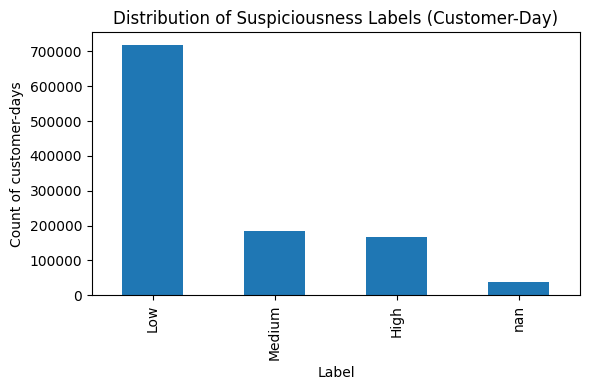

suspiciousness_label
Low       718664
Medium    183822
High      166916
NaN        36862
Name: count, dtype: int64

In [125]:
label_counts = customer_day["suspiciousness_label"].value_counts(dropna=False)

plt.figure(figsize=(6,4))
label_counts.plot(kind="bar")
plt.title("Distribution of Suspiciousness Labels (Customer-Day)")
plt.xlabel("Label")
plt.ylabel("Count of customer-days")
plt.tight_layout()
plt.show()

label_counts


### **Velocity Group vs Value Group**

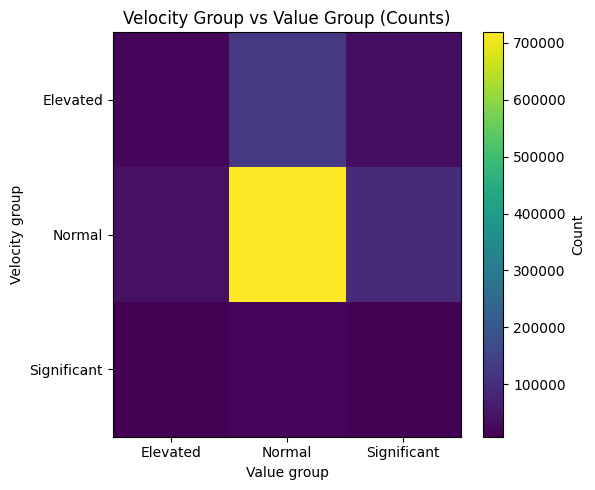

value_group,Elevated,Normal,Significant
velocity_group,,,
Elevated,19878,125369,33529
Normal,38575,718664,95869
Significant,7445,18892,11181


In [126]:
ct = pd.crosstab(customer_day["velocity_group"], customer_day["value_group"])

plt.figure(figsize=(6,5))
plt.imshow(ct, aspect="auto")
plt.xticks(range(len(ct.columns)), ct.columns)
plt.yticks(range(len(ct.index)), ct.index)
plt.title("Velocity Group vs Value Group (Counts)")
plt.xlabel("Value group")
plt.ylabel("Velocity group")
plt.colorbar(label="Count")
plt.tight_layout()
plt.show()

ct


### **Label Distribution by Channel (Transaction-Level)**

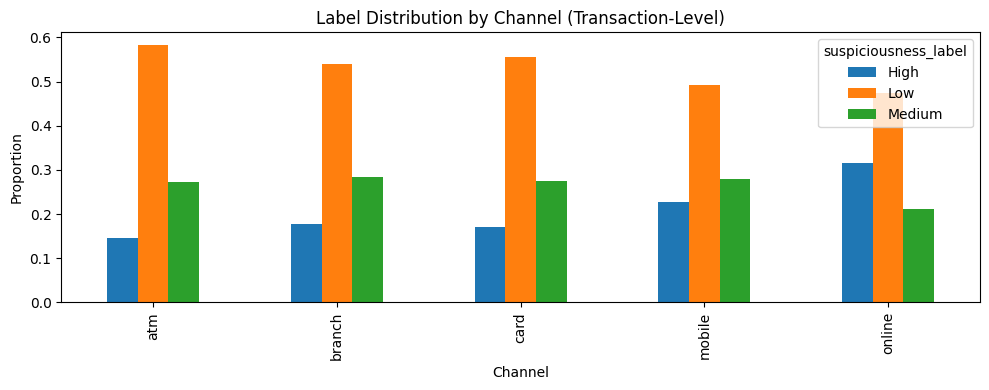

suspiciousness_label,High,Low,Medium
channel,,,
atm,0.145584,0.582320,0.272096
branch,0.176534,0.539991,0.283475
card,0.169823,0.555776,0.274401
mobile,0.228247,0.492448,0.279305
online,0.316252,0.473135,0.210613


In [127]:
channel_label = pd.crosstab(
    transactions_labeled["channel"],
    transactions_labeled["suspiciousness_label"],
    normalize="index"
)

channel_label.plot(kind="bar", figsize=(10,4))
plt.title("Label Distribution by Channel (Transaction-Level)")
plt.xlabel("Channel")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

channel_label


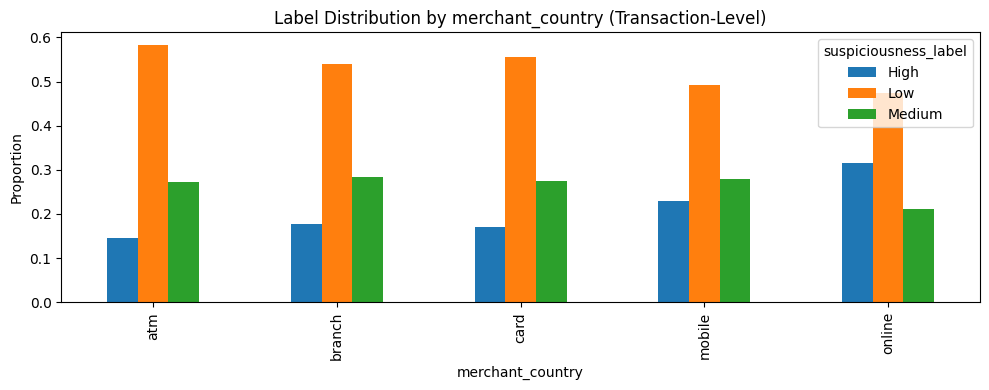

suspiciousness_label,High,Low,Medium
merchant_country,,,
CH,0.242616,0.491561,0.265823
DE,0.199673,0.518645,0.281682
DK,0.199194,0.472654,0.328152
EE,0.219187,0.528031,0.252782
ES,0.216800,0.496603,0.286597
FI,0.184891,0.535893,0.279215
FR,0.199501,0.520881,0.279619
GB,0.201376,0.514402,0.284221
IT,0.221648,0.501962,0.276389


In [128]:
merchant_country_label = pd.crosstab(
    transactions_labeled["merchant_country"],
    transactions_labeled["suspiciousness_label"],
    normalize="index"
)

channel_label.plot(kind="bar", figsize=(10,4))
plt.title("Label Distribution by merchant_country (Transaction-Level)")
plt.xlabel("merchant_country")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

merchant_country_label